## Sampling Klein filters

A Gabor filter is a function on $[-1,1]^2$

The Klein subset of Gabor filters is given by (see formula (9), and later formulae page 15, of [`Topological Convolutional Layers for Deep Learning`](https://www.jmlr.org/papers/volume24/21-0073/21-0073.pdf#page=15)) 

$$\tilde{g}(\theta_1, \theta_2) = -\cos\left(\frac{\pi\cdot x'(\theta_1)}{1+2\theta_2/\pi}+\theta_2\right)$$

where 

$$x'(\omega)=x\cos(\omega)+y\sin(\omega)$$

**Note** that $\tilde{g}(\theta_1, \theta_2)$ is $2\pi$-periodic in $\theta_1$, but **not exactly** $2\pi$-periodic in $\theta_2$!

In [12]:
import numpy as np

import matplotlib.pyplot as plt

In [10]:
class GK:
    """
    Gabor-Klein filter
    """
    def __init__(self, theta1, theta2):
        self.th1 = theta1
        self.th2 = theta2
        
    def f(self,xs,ys):
        """
        Input: xs, ys - 2d meshgrids
        built from linspace(-1,1,n_points)
        """
        x_prime = xs*np.cos(self.th1)+ys*np.sin(self.th1)
        frac = np.pi*x_prime
        frac /= (1+2*self.th2/np.pi)
        return -1*np.cos(frac + self.th2)

In [61]:
n_points = 5

xs = np.linspace(-1, 1, n_points)
ys = np.linspace(-1, 1, n_points)

xv, yv = np.meshgrid(xs, ys)

Text(0.5, 0.01, 'θ₂ from 0 to 2pi')

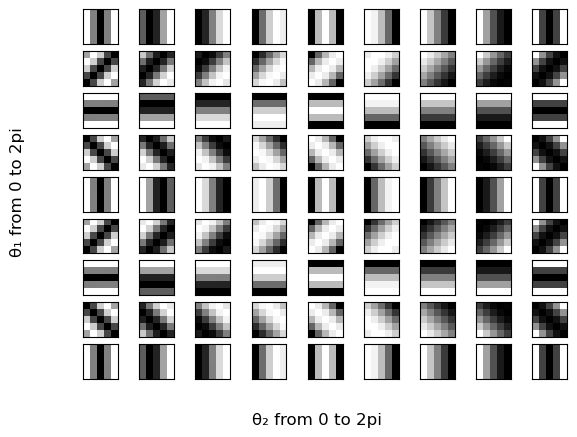

In [63]:
n = 8

fig, ax = plt.subplots(n+1,n+1)

for i in range(0,n+1):
    for j in range(0,n+1):
        
        ax[i,j].imshow(GK((2*np.pi/8)*i,(2*np.pi/8)*j).f(xv,yv), 
                        cmap='gray')
        ax[i,j].axes.get_xaxis().set_ticks([])
        ax[i,j].axes.get_yaxis().set_ticks([])
        
        # for showing indices
        #ax[i,j].set_title(f'{i},{j}')
        
# i - theta1 - 2pi-periodic
# j - theta2 - ALMOST 2pi-periodic

fig.supylabel('θ₁ from 0 to 2pi')
fig.supxlabel('θ₂ from 0 to 2pi')